# DQN Network Depth Ablation Study

This notebook tests how the number of hidden layers affects DQN performance on LunarLander. Unlike a single-run comparison, this version uses multiple random seeds and an independent evaluation phase, which gives a more objective estimate of whether network depth actually improves performance.

**Baseline:** num_layers = 2

## 1. Setup and Imports

In [6]:
import os
import random
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from gymnasium import make

# Import from vanilla DQN module
sys.path.insert(0, os.path.abspath('..'))

from core.vanilla_dqn_lunar_lander import VanillaDQN, device, save_results, save_model, save_plot

## 2. Reproducibility and Evaluation Helpers

In [7]:
def set_global_seed(seed):
    """Set Python, NumPy, and PyTorch seeds for a more controlled comparison."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def evaluate_agent(agent, num_episodes=20, seed=0):
    """Evaluate a trained policy without epsilon exploration."""
    env = make('LunarLander-v3')
    env.action_space.seed(seed + 10_000)

    eval_rewards = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + 10_000 + episode)
        episode_reward = 0
        done = False

        while not done:
            action = agent.select_action(state, training=False)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward

        eval_rewards.append(episode_reward)

    env.close()
    return eval_rewards


def smooth_curve(values, window=50):
    """Return a moving average curve."""
    values = np.asarray(values, dtype=float)
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window) / window, mode='valid')

## 3. Training Function (Seeded)

In [8]:
def train_dqn(num_episodes=500, batch_size=32, update_frequency=4, target_update_frequency=100,
              num_layers=2, hidden_dim=128, epsilon_decay=0.995, learning_rate=1e-3,
              seed=0, verbose=True):
    """Train a DQN agent on LunarLander with configurable network depth and seed."""
    set_global_seed(seed)

    # Create environment
    env = make('LunarLander-v3')
    env.action_space.seed(seed)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent with specified network depth
    agent = VanillaDQN(
        state_dim,
        action_dim,
        learning_rate=learning_rate,
        epsilon_decay=epsilon_decay,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
    )

    # Training loop
    episode_rewards = []
    episode_losses = []
    epsilon_history = []

    for episode in range(num_episodes):
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0
        episode_loss = []
        done = False
        step = 0

        while not done:
            action = agent.select_action(state, training=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            agent.store_transition(state, action, reward, next_state, done)

            if step % update_frequency == 0:
                loss = agent.update(batch_size)
                if loss is not None:
                    episode_loss.append(loss)

            episode_reward += reward
            state = next_state
            step += 1

        if (episode + 1) % target_update_frequency == 0:
            agent.update_target_network()

        agent.decay_epsilon()

        episode_rewards.append(episode_reward)
        epsilon_history.append(agent.epsilon)
        if episode_loss:
            episode_losses.append(np.mean(episode_loss))

        if verbose and (episode + 1) % 100 == 0:
            avg_reward = np.mean(episode_rewards[-100:])
            print(
                f"  Episode {episode + 1}/{num_episodes} | "
                f"Avg Reward (last 100): {avg_reward:.2f} | "
                f"Epsilon: {agent.epsilon:.4f}"
            )

    env.close()

    return agent, episode_rewards, episode_losses, epsilon_history

## 4. Ablation Study: Multiple Depths and Seeds

In [5]:
# Network depths to test. num_layers means the number of hidden Linear layers in QNetwork.
num_layer_values = [1, 2, 3, 4, 5]
seeds = [0, 1, 2, 3, 4]

num_episodes = 500
evaluation_episodes = 20

# Fixed hyperparameters for this ablation
hidden_dim = 128
learning_rate = 1e-3
epsilon_decay = 0.995
batch_size = 32
update_frequency = 4
target_update_frequency = 100

# Store all runs
results = {num_layers: [] for num_layers in num_layer_values}
run_records = []

print("=" * 80)
print("DQN Network Depth Ablation Study")
print(f"Testing {len(num_layer_values)} depths x {len(seeds)} seeds = {len(num_layer_values) * len(seeds)} training runs")
print(f"Training episodes per run: {num_episodes} | Evaluation episodes per run: {evaluation_episodes}")
print("=" * 80)

for num_layers in num_layer_values:
    for seed in seeds:
        print(f"\nTraining DQN with num_layers = {num_layers}, seed = {seed}")
        agent, rewards, losses, epsilon_history = train_dqn(
            num_episodes=num_episodes,
            batch_size=batch_size,
            update_frequency=update_frequency,
            target_update_frequency=target_update_frequency,
            num_layers=num_layers,
            hidden_dim=hidden_dim,
            epsilon_decay=epsilon_decay,
            learning_rate=learning_rate,
            seed=seed,
        )

        eval_rewards = evaluate_agent(agent, num_episodes=evaluation_episodes, seed=seed)

        hyperparameters = {
            'learning_rate': learning_rate,
            'num_layers': num_layers,
            'hidden_dim': hidden_dim,
            'epsilon_decay': epsilon_decay,
            'batch_size': batch_size,
            'num_episodes': num_episodes,
            'evaluation_episodes': evaluation_episodes,
            'seed': seed,
            'update_frequency': update_frequency,
            'target_update_frequency': target_update_frequency,
        }

        variant_name = f'{num_layers}_seed_{seed}'

        # Results saved to: results/ablations/num_layers/{num_layers}_seed_{seed}/
        save_results(agent, rewards, losses, hyperparameters,
                     experiment_name='num_layers', variant_name=variant_name)
        save_model(agent, experiment_name='num_layers', variant_name=variant_name)
        save_plot(rewards, losses, experiment_name='num_layers', variant_name=variant_name)

        run_result = {
            'agent': agent,
            'rewards': rewards,
            'losses': losses,
            'epsilon_history': epsilon_history,
            'eval_rewards': eval_rewards,
            'seed': seed,
        }
        results[num_layers].append(run_result)

        run_records.append({
            'Num Layers': num_layers,
            'Seed': seed,
            'Best Training Reward': max(rewards),
            'Training Avg Last 100': np.mean(rewards[-100:]),
            'Training Avg Last 25': np.mean(rewards[-25:]),
            'Training Mean Reward': np.mean(rewards),
            'Training Std Reward': np.std(rewards),
            'Evaluation Avg Reward': np.mean(eval_rewards),
            'Evaluation Std Reward': np.std(eval_rewards),
            'Mean Loss': np.mean(losses) if losses else np.nan,
        })

        print(
            f"  Evaluation Avg Reward: {np.mean(eval_rewards):.2f} "
            f"+/- {np.std(eval_rewards):.2f}"
        )

print("\n" + "=" * 80)
print("Training and Evaluation Complete!")
print("=" * 80)

DQN Network Depth Ablation Study
Testing 5 depths x 5 seeds = 25 training runs
Training episodes per run: 500 | Evaluation episodes per run: 20

Training DQN with num_layers = 1, seed = 0
  Episode 100/500 | Avg Reward (last 100): -217.17 | Epsilon: 0.6058
  Episode 200/500 | Avg Reward (last 100): -163.68 | Epsilon: 0.3670
  Episode 300/500 | Avg Reward (last 100): -129.34 | Epsilon: 0.2223
  Episode 400/500 | Avg Reward (last 100): -76.37 | Epsilon: 0.1347
  Episode 500/500 | Avg Reward (last 100): -51.73 | Epsilon: 0.0816
Results saved to c:\Users\yuezh\Desktop\COMP3242-Group-Project-DQN\results\ablations\num_layers\1_seed_0\results.pkl
Model saved to c:\Users\yuezh\Desktop\COMP3242-Group-Project-DQN\results\ablations\num_layers\1_seed_0\model.pt
Plot saved to c:\Users\yuezh\Desktop\COMP3242-Group-Project-DQN\results\ablations\num_layers\1_seed_0\plot.png
  Evaluation Avg Reward: -31.68 +/- 156.58

Training DQN with num_layers = 1, seed = 1
  Episode 100/500 | Avg Reward (last 100):

KeyboardInterrupt: 

## 5. Per-Run Results

In [5]:
run_df = pd.DataFrame(run_records)
run_df = run_df.sort_values(['Num Layers', 'Seed']).reset_index(drop=True)

print("\n" + "=" * 80)
print("PER-RUN RESULTS")
print("=" * 80)
print(run_df.to_string(index=False))

summary_dir = os.path.abspath('../results/ablations/num_layers')
os.makedirs(summary_dir, exist_ok=True)
run_df.to_csv(os.path.join(summary_dir, 'per_seed_summary.csv'), index=False)


PER-RUN RESULTS
 Num Layers  Seed  Best Training Reward  Training Avg Last 100  Training Avg Last 25  Training Mean Reward  Training Std Reward  Evaluation Avg Reward  Evaluation Std Reward  Mean Loss
          1     0            270.592954             -51.728821            -63.303572           -127.658397           142.875569             -31.681959             156.579067  39.965770
          1     1            274.603862             -73.039564            -66.025567           -106.851158           123.825876             -39.111379             128.142567  36.398480
          1     2            304.434585             -53.883310            -71.794611            -98.967180           132.810544             -24.825486             147.332265  38.133380
          1     3            288.536600             -60.535439              2.018778           -107.712578           124.165145             -33.006355             178.080294  36.836062
          1     4            305.051402             -63.57

## 6. Aggregated Summary Statistics

In [6]:
summary_df = (
    run_df
    .groupby('Num Layers')
    .agg(
        Runs=('Seed', 'count'),
        Train_Last100_Mean=('Training Avg Last 100', 'mean'),
        Train_Last100_Std=('Training Avg Last 100', 'std'),
        Eval_Mean=('Evaluation Avg Reward', 'mean'),
        Eval_Std=('Evaluation Avg Reward', 'std'),
        Best_Reward_Mean=('Best Training Reward', 'mean'),
        Mean_Reward_Mean=('Training Mean Reward', 'mean'),
        Mean_Loss=('Mean Loss', 'mean'),
    )
    .reset_index()
)

summary_df['Eval_SEM'] = summary_df['Eval_Std'] / np.sqrt(summary_df['Runs'])
summary_df['Train_Last100_SEM'] = summary_df['Train_Last100_Std'] / np.sqrt(summary_df['Runs'])

print("\n" + "=" * 80)
print("AGGREGATED SUMMARY ACROSS SEEDS")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

summary_df.to_csv(os.path.join(summary_dir, 'aggregated_summary.csv'), index=False)


AGGREGATED SUMMARY ACROSS SEEDS
 Num Layers  Runs  Train_Last100_Mean  Train_Last100_Std   Eval_Mean   Eval_Std  Best_Reward_Mean  Mean_Reward_Mean  Mean_Loss  Eval_SEM  Train_Last100_SEM
          1     5          -60.553215           8.476759  -34.715724   7.649757        288.643880       -110.990569  37.928785  3.421075           3.790922
          2     5          -38.845300          38.790054  -93.972153  97.035147        281.316998        -95.568834  32.137560 43.395437          17.347440
          3     5           -7.738910          39.598110   -0.258618  83.121880        287.676482        -89.151051  32.120451 37.173235          17.708813
          4     5          -74.040219          47.005172 -120.851774  78.241177        286.128240       -111.054197  32.646520 34.990518          21.021352
          5     5          -54.636130          23.163883 -111.215506 140.244604        277.946836       -117.627128  34.362620 62.719294          10.359204


## 7. Visualization: Mean Training Curves with Error Bands

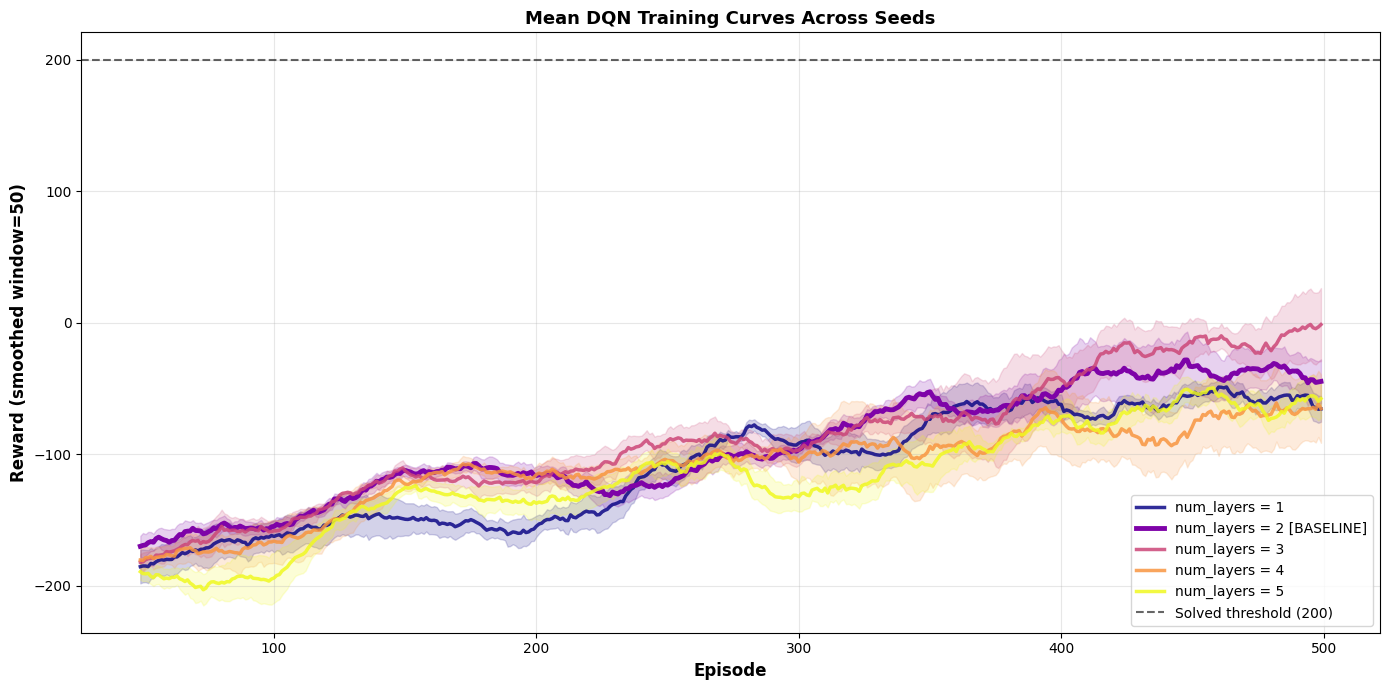

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = plt.cm.plasma(np.linspace(0, 1, len(num_layer_values)))
window = 50

for idx, num_layers in enumerate(num_layer_values):
    smoothed_runs = []
    for run in results[num_layers]:
        smoothed_runs.append(smooth_curve(run['rewards'], window=window))

    min_len = min(len(curve) for curve in smoothed_runs)
    curves = np.array([curve[-min_len:] for curve in smoothed_runs])

    mean_curve = curves.mean(axis=0)
    sem_curve = curves.std(axis=0, ddof=1) / np.sqrt(curves.shape[0])
    x_values = np.arange(num_episodes - min_len, num_episodes)

    linewidth = 3.5 if num_layers == 2 else 2.5
    alpha = 1.0 if num_layers == 2 else 0.85

    ax.plot(
        x_values,
        mean_curve,
        linewidth=linewidth,
        alpha=alpha,
        color=colors[idx],
        label=f'num_layers = {num_layers}' + (' [BASELINE]' if num_layers == 2 else ''),
    )
    ax.fill_between(x_values, mean_curve - sem_curve, mean_curve + sem_curve,
                    color=colors[idx], alpha=0.18)

ax.axhline(200, color='black', linestyle='--', linewidth=1.5, alpha=0.6, label='Solved threshold (200)')
ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
ax.set_ylabel(f'Reward (smoothed window={window})', fontsize=12, fontweight='bold')
ax.set_title('Mean DQN Training Curves Across Seeds', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Visualization: Training and Evaluation Comparison

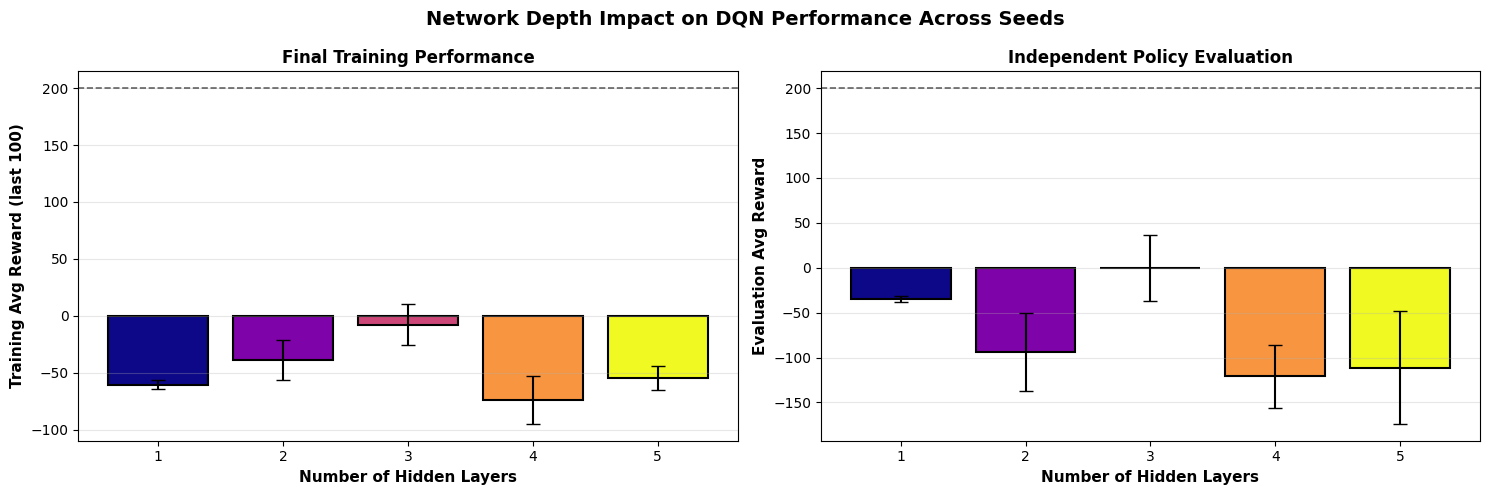

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors_bar = plt.cm.plasma(np.linspace(0, 1, len(summary_df)))
x = np.arange(len(summary_df))
labels = summary_df['Num Layers'].astype(str)

# Plot 1: Training final performance across seeds
axes[0].bar(
    x,
    summary_df['Train_Last100_Mean'],
    yerr=summary_df['Train_Last100_SEM'],
    color=colors_bar,
    edgecolor='black',
    linewidth=1.5,
    capsize=5,
)
axes[0].axhline(200, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Training Avg Reward (last 100)', fontsize=11, fontweight='bold')
axes[0].set_title('Final Training Performance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Independent evaluation performance across seeds
axes[1].bar(
    x,
    summary_df['Eval_Mean'],
    yerr=summary_df['Eval_SEM'],
    color=colors_bar,
    edgecolor='black',
    linewidth=1.5,
    capsize=5,
)
axes[1].axhline(200, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Evaluation Avg Reward', fontsize=11, fontweight='bold')
axes[1].set_title('Independent Policy Evaluation', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Network Depth Impact on DQN Performance Across Seeds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Visualization: Distribution Across Seeds

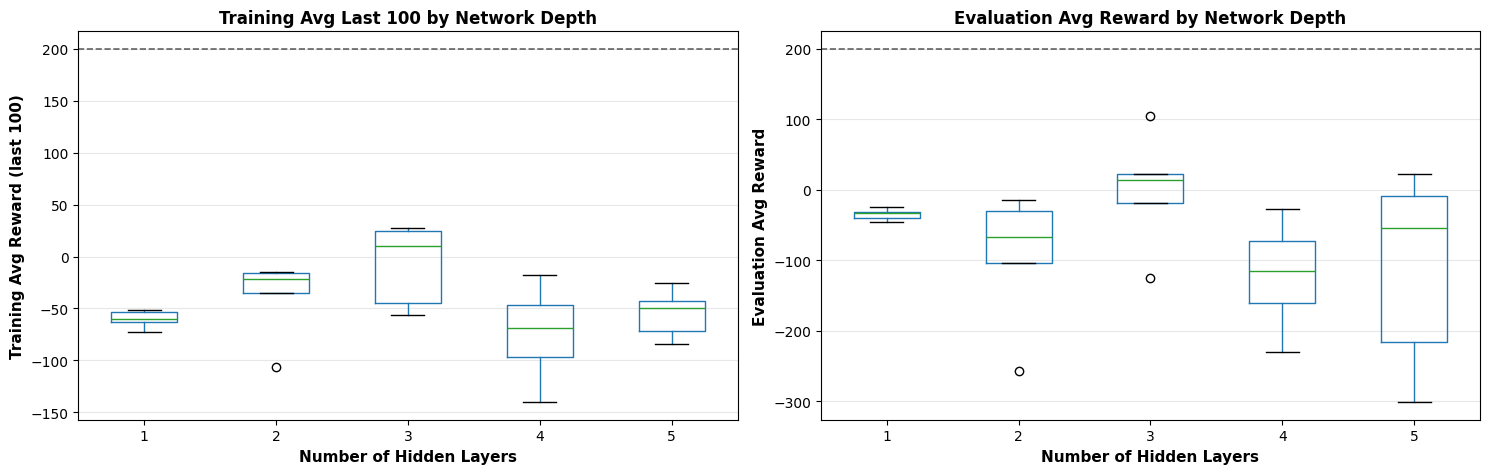

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

run_df.boxplot(column='Training Avg Last 100', by='Num Layers', ax=axes[0], grid=False)
axes[0].axhline(200, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[0].set_title('Training Avg Last 100 by Network Depth', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Training Avg Reward (last 100)', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

run_df.boxplot(column='Evaluation Avg Reward', by='Num Layers', ax=axes[1], grid=False)
axes[1].axhline(200, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1].set_title('Evaluation Avg Reward by Network Depth', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Hidden Layers', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Evaluation Avg Reward', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 10. Key Findings

In [10]:
best_train_idx = summary_df['Train_Last100_Mean'].idxmax()
best_eval_idx = summary_df['Eval_Mean'].idxmax()

best_train_layers = int(summary_df.loc[best_train_idx, 'Num Layers'])
best_eval_layers = int(summary_df.loc[best_eval_idx, 'Num Layers'])

print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)
print(
    f"Best final training performer: num_layers = {best_train_layers} | "
    f"Last-100 mean = {summary_df.loc[best_train_idx, 'Train_Last100_Mean']:.2f} "
    f"+/- {summary_df.loc[best_train_idx, 'Train_Last100_SEM']:.2f} SEM"
)
print(
    f"Best evaluation performer: num_layers = {best_eval_layers} | "
    f"Eval mean = {summary_df.loc[best_eval_idx, 'Eval_Mean']:.2f} "
    f"+/- {summary_df.loc[best_eval_idx, 'Eval_SEM']:.2f} SEM"
)

baseline = summary_df[summary_df['Num Layers'] == 2].iloc[0]
print("\nBaseline (num_layers = 2):")
print(f"  Training Avg Last 100: {baseline['Train_Last100_Mean']:.2f} +/- {baseline['Train_Last100_SEM']:.2f} SEM")
print(f"  Evaluation Avg Reward: {baseline['Eval_Mean']:.2f} +/- {baseline['Eval_SEM']:.2f} SEM")

solved_layers = summary_df[summary_df['Eval_Mean'] >= 200]['Num Layers'].tolist()
if solved_layers:
    print(f"\nSolved threshold reached in evaluation by: {solved_layers}")
else:
    print("\nNo network depth reached the solved threshold of 200 average evaluation reward.")

print("\nInterpretation guidance:")
print("  - Prefer evaluation reward for final policy quality because training reward is affected by epsilon exploration.")
print("  - Compare means together with SEM/std; overlapping error bars indicate weak evidence for a true difference.")
print("  - If deeper networks do not improve evaluation reward, the extra capacity may be harder to optimize under this DQN setup.")
print("\n" + "=" * 80)


KEY FINDINGS
Best final training performer: num_layers = 3 | Last-100 mean = -7.74 +/- 17.71 SEM
Best evaluation performer: num_layers = 3 | Eval mean = -0.26 +/- 37.17 SEM

Baseline (num_layers = 2):
  Training Avg Last 100: -38.85 +/- 17.35 SEM
  Evaluation Avg Reward: -93.97 +/- 43.40 SEM

No network depth reached the solved threshold of 200 average evaluation reward.

Interpretation guidance:
  - Prefer evaluation reward for final policy quality because training reward is affected by epsilon exploration.
  - Compare means together with SEM/std; overlapping error bars indicate weak evidence for a true difference.
  - If deeper networks do not improve evaluation reward, the extra capacity may be harder to optimize under this DQN setup.

